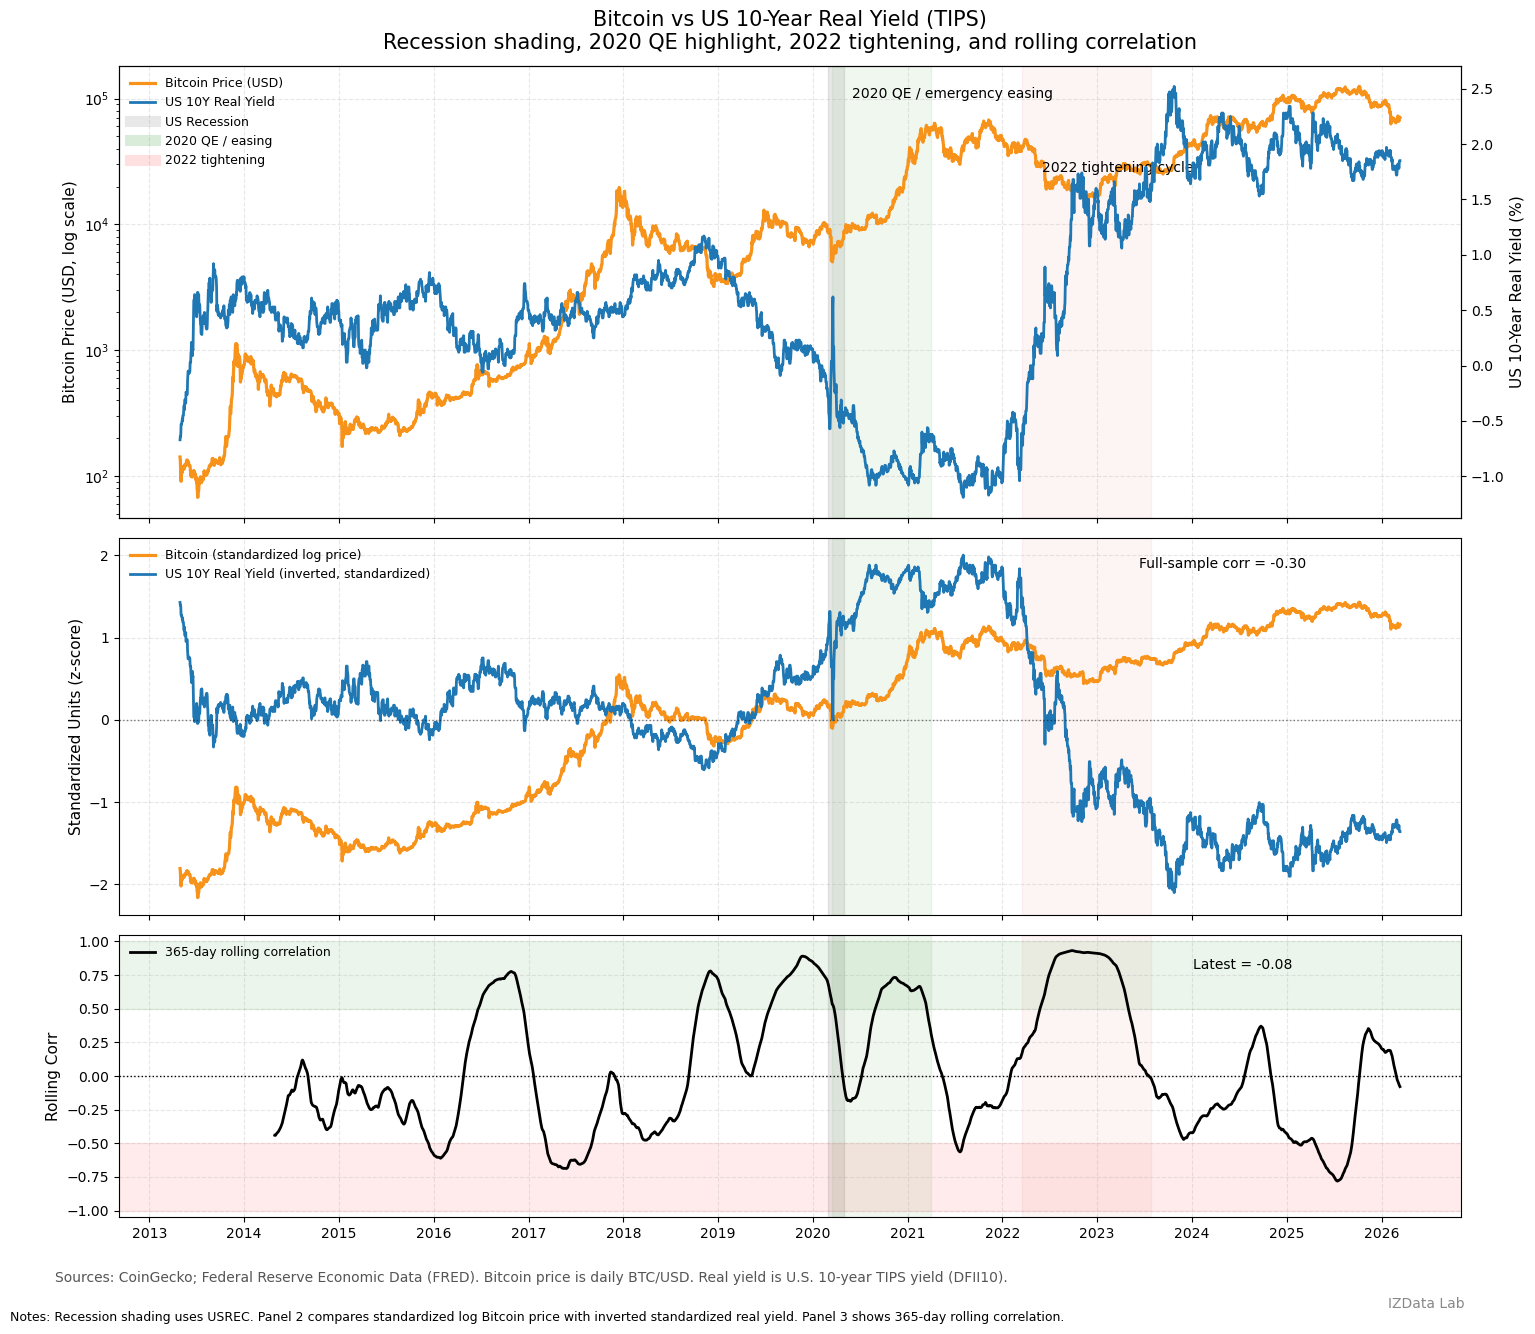

BTC date range: 2013-04-28 00:00:00 to 2026-03-13 00:00:00
TIPS date range: 2003-01-02 00:00:00 to 2026-03-11 00:00:00
REC date range: 1854-12-01 00:00:00 to 2026-02-01 00:00:00
Merged df shape: (4700, 8)
Full-sample correlation: -0.296
               BTC  RealYield  Recession
Date                                    
2013-04-29  141.96      -0.67        0.0
2013-04-30  135.30      -0.64        0.0
2013-05-01  117.00      -0.64        0.0
2013-05-02  103.43      -0.62        0.0
2013-05-03   91.01      -0.53        0.0
              BTC_Z  RealYield_Z_Inverted  RollingCorr_365d
count  4.700000e+03          4.700000e+03       4336.000000
mean   3.870190e-16         -8.466041e-17          0.054134
std    1.000000e+00          1.000000e+00          0.478496
min   -2.159930e+00         -2.099787e+00         -0.780989
25%   -1.067900e+00         -7.621991e-01         -0.326456
50%    1.858621e-01          1.111019e-01         -0.070181
75%    8.808618e-01          5.201163e-01          0.494

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ==========================================
# Helper: identify columns
# ==========================================
def find_column(columns, candidates):
    candidates_lower = [c.lower() for c in candidates]
    for col in columns:
        if col.strip().lower() in candidates_lower:
            return col
    return None

# ==========================================
# Helper: convert datetime to timezone-naive
# ==========================================
def to_naive_datetime(series):
    dt = pd.to_datetime(series, errors="coerce", utc=True)
    return dt.dt.tz_convert(None)

# ==========================================
# Helper: recession shading
# ==========================================
def shade_recessions(ax, data):
    rec_series = data["Recession"].fillna(0)
    in_rec = False
    rec_start = None

    for dt, val in rec_series.items():
        if val == 1 and not in_rec:
            in_rec = True
            rec_start = dt
        elif val == 0 and in_rec:
            in_rec = False
            ax.axvspan(rec_start, dt, color="gray", alpha=0.18)

    if in_rec:
        ax.axvspan(rec_start, rec_series.index[-1], color="gray", alpha=0.18)

# ==========================================
# 1. Load Bitcoin price data
# ==========================================
btc = pd.read_csv("btc_usd.csv")
btc.columns = [col.strip() for col in btc.columns]

btc_date_col = find_column(btc.columns, ["date", "datetime", "timestamp"])
btc_price_col = find_column(btc.columns, ["close", "price", "btc", "adj close", "adj_close"])

if btc_date_col is None:
    raise ValueError(f"Could not find a date column in btc_usd.csv. Found columns: {list(btc.columns)}")

if btc_price_col is None:
    raise ValueError(f"Could not find a BTC price column in btc_usd.csv. Found columns: {list(btc.columns)}")

btc[btc_date_col] = to_naive_datetime(btc[btc_date_col])
btc = btc.rename(columns={btc_date_col: "Date", btc_price_col: "BTC"})

btc["BTC"] = pd.to_numeric(btc["BTC"], errors="coerce")
btc = btc.dropna(subset=["Date", "BTC"]).copy()

btc["Date"] = btc["Date"].dt.normalize()
btc = btc.sort_values("Date")
btc = btc.groupby("Date", as_index=False)["BTC"].last()
btc = btc.set_index("Date")

# ==========================================
# 2. Load TIPS real yield data
# ==========================================
tips = pd.read_csv("DFII10.csv")
tips.columns = [col.strip() for col in tips.columns]

tips_date_col = find_column(tips.columns, ["date", "observation_date"])
tips_yield_col = find_column(tips.columns, ["dfii10", "realyield", "real_yield"])

if tips_date_col is None or tips_yield_col is None:
    raise ValueError(f"Could not identify columns in DFII10.csv. Found columns: {list(tips.columns)}")

tips[tips_date_col] = to_naive_datetime(tips[tips_date_col])
tips = tips.rename(columns={tips_date_col: "Date", tips_yield_col: "RealYield"})

tips["RealYield"] = pd.to_numeric(tips["RealYield"], errors="coerce")
tips = tips.dropna(subset=["Date", "RealYield"]).copy()

tips["Date"] = tips["Date"].dt.normalize()
tips = tips.sort_values("Date")
tips = tips.groupby("Date", as_index=False)["RealYield"].last()
tips = tips.set_index("Date")

# ==========================================
# 3. Load recession indicator
# ==========================================
rec = pd.read_csv("USREC.csv")
rec.columns = [col.strip() for col in rec.columns]

rec_date_col = find_column(rec.columns, ["date", "observation_date"])
rec_flag_col = find_column(rec.columns, ["usrec", "recession"])

if rec_date_col is None or rec_flag_col is None:
    raise ValueError(f"Could not identify columns in USREC.csv. Found columns: {list(rec.columns)}")

rec[rec_date_col] = to_naive_datetime(rec[rec_date_col])
rec = rec.rename(columns={rec_date_col: "Date", rec_flag_col: "Recession"})

rec["Recession"] = pd.to_numeric(rec["Recession"], errors="coerce")
rec = rec.dropna(subset=["Date", "Recession"]).copy()

rec["Date"] = rec["Date"].dt.normalize()
rec = rec.sort_values("Date")
rec = rec.groupby("Date", as_index=False)["Recession"].last()
rec = rec.set_index("Date")

# ==========================================
# 4. Merge datasets
# ==========================================
df = btc.join(tips, how="left")
df = df.join(rec, how="left")

# Forward-fill macro series to BTC daily calendar
df["RealYield"] = df["RealYield"].ffill()
df["Recession"] = df["Recession"].ffill().fillna(0)

df = df.dropna(subset=["BTC", "RealYield"]).copy()

if df.empty:
    raise ValueError(
        "Merged dataframe is empty. Check date overlap across btc_usd.csv, DFII10.csv, and USREC.csv."
    )

# Optional: restrict to modern macro period if desired
# df = df.loc["2019-01-01":].copy()

# ==========================================
# 5. Build transformed series
# ==========================================
# Standardized comparison panel
df["BTC_Log"] = np.log(df["BTC"])
df["BTC_Z"] = (df["BTC_Log"] - df["BTC_Log"].mean()) / df["BTC_Log"].std()

df["RealYield_Z"] = (df["RealYield"] - df["RealYield"].mean()) / df["RealYield"].std()
df["RealYield_Z_Inverted"] = -df["RealYield_Z"]

# Rolling correlation
window = 365  # about 1 trading year
df["RollingCorr_365d"] = (
    df["BTC_Z"]
    .rolling(window=window, min_periods=window)
    .corr(df["RealYield_Z_Inverted"])
)

# Full-sample correlation
corr_full = df["BTC_Z"].corr(df["RealYield_Z_Inverted"])

# ==========================================
# 6. Macro windows
# ==========================================
qe_start = pd.Timestamp("2020-03-15")
qe_end   = pd.Timestamp("2021-03-31")

tight_start = pd.Timestamp("2022-03-16")
tight_end   = pd.Timestamp("2023-07-26")

# ==========================================
# 7. Create 3-panel chart
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(15, 13),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1, 0.75]}
)

# --------------------------
# Panel 1: BTC vs Real Yield
# --------------------------
shade_recessions(ax1, df)

ax1.plot(
    df.index,
    df["BTC"],
    color="#f7931a",
    linewidth=2.3,
    label="Bitcoin Price (USD)"
)
ax1.set_yscale("log")
ax1.set_ylabel("Bitcoin Price (USD, log scale)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(
    df.index,
    df["RealYield"],
    color="#1f77b4",
    linewidth=2.0,
    label="US 10Y Real Yield (TIPS)"
)
ax1b.set_ylabel("US 10-Year Real Yield (%)", fontsize=11)


ax1.axvspan(qe_start, qe_end, color="#7fbf7b", alpha=0.12)
ax1.axvspan(tight_start, tight_end, color="#f4a6a6", alpha=0.12)

ymin, ymax = ax1.get_ylim()
ax1.text(pd.Timestamp("2020-06-01"), ymax / 1.8, "2020 QE / emergency easing", fontsize=10)
ax1.text(pd.Timestamp("2022-06-01"), ymax / 7, "2022 tightening cycle", fontsize=10)

ax1.set_title(
    "Bitcoin vs US 10-Year Real Yield (TIPS)\n"
    "Recession shading, 2020 QE highlight, 2022 tightening, and rolling correlation",
    fontsize=15,
    pad=12
)

handles_panel1 = [
    Line2D([0], [0], color="#f7931a", linewidth=2.3, label="Bitcoin Price (USD)"),
    Line2D([0], [0], color="#1f77b4", linewidth=2.0, label="US 10Y Real Yield"),
    Line2D([0], [0], color="gray", linewidth=8, alpha=0.18, label="US Recession"),
    Line2D([0], [0], color="green", linewidth=8, alpha=0.15, label="2020 QE / easing"),
    Line2D([0], [0], color="red", linewidth=8, alpha=0.12, label="2022 tightening"),
]
ax1.legend(handles=handles_panel1, loc="upper left", frameon=False, fontsize=9)

# --------------------------
# Panel 2: Standardized comparison
# --------------------------
shade_recessions(ax2, df)

ax2.plot(
    df.index,
    df["BTC_Z"],
    color="#f7931a",
    linewidth=2.3,
    label="Bitcoin (standardized log price)"
)
ax2.plot(
    df.index,
    df["RealYield_Z_Inverted"],
    color="#1f77b4",
    linewidth=2.0,
    label="US 10Y Real Yield (inverted, standardized)"
)

ax2.axvspan(qe_start, qe_end, color="#7fbf7b", alpha=0.12)
ax2.axvspan(tight_start, tight_end, color="#f4a6a6", alpha=0.12)

ax2.axhline(0, color="black", linewidth=1, linestyle=":", alpha=0.5)
ax2.set_ylabel("Standardized Units (z-score)", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend(loc="upper left", frameon=False, fontsize=9)

ax2.text(
    0.76, 0.92,
    f"Full-sample corr = {corr_full:.2f}",
    transform=ax2.transAxes,
    fontsize=10
)

# --------------------------
# Panel 3: Rolling correlation
# --------------------------
shade_recessions(ax3, df)

ax3.plot(
    df.index,
    df["RollingCorr_365d"],
    color="black",
    linewidth=2.0,
    label="365-day rolling correlation"
)

ax3.axhline(0, color="black", linewidth=1, linestyle=":")
ax3.axvspan(qe_start, qe_end, color="#7fbf7b", alpha=0.12)
ax3.axvspan(tight_start, tight_end, color="#f4a6a6", alpha=0.12)

ax3.set_ylabel("Rolling Corr", fontsize=11)
ax3.set_ylim(-1.05, 1.05)
ax3.grid(True, linestyle="--", alpha=0.3)
ax3.legend(loc="upper left", frameon=False, fontsize=9)

latest_corr = df["RollingCorr_365d"].dropna()
if not latest_corr.empty:
    ax3.text(
        0.80, 0.88,
        f"Latest = {latest_corr.iloc[-1]:.2f}",
        transform=ax3.transAxes,
        fontsize=10
    )

# X-axis formatting
ax3.xaxis.set_major_locator(mdates.YearLocator(1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

ax3.axhspan(0.5, 1, color="green", alpha=0.08)
ax3.axhspan(-1, -0.5, color="red", alpha=0.08)

# Footer note
fig.text(
    -0.02, -0.02,
    "Notes: Recession shading uses USREC. "
    "Panel 2 compares standardized log Bitcoin price with inverted standardized real yield. "
    "Panel 3 shows 365-day rolling correlation.",
    fontsize=9
)

fig.text(
    0.01,
    0.01,
    "Sources: CoinGecko; Federal Reserve Economic Data (FRED). "
    "Bitcoin price is daily BTC/USD. Real yield is U.S. 10-year TIPS yield (DFII10).",
    ha="left",
    fontsize=10,
    color="#555555"
)


fig.text(
    0.95, -0.01,
    "IZData Lab",
    fontsize=10,
    color="#888888",
    ha="right"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("Bitcoin_vs_TIPS.png", dpi=300, bbox_inches="tight")
plt.show()

# ==========================================
# 8. Optional diagnostics
# ==========================================
print("BTC date range:", btc.index.min(), "to", btc.index.max())
print("TIPS date range:", tips.index.min(), "to", tips.index.max())
print("REC date range:", rec.index.min(), "to", rec.index.max())
print("Merged df shape:", df.shape)
print("Full-sample correlation:", round(corr_full, 3))
print(df[["BTC", "RealYield", "Recession"]].head())
print(df[["BTC_Z", "RealYield_Z_Inverted", "RollingCorr_365d"]].describe())
